In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import src.fluorophore_systems as fs
import src.figures as fi
import src.distributions as d

%load_ext autoreload
%autoreload 2

# Binned photon counts 
Intensity distributions based on different photon count bin sizes

### 1 fluorophore, S0 S1 T1 Cis system

In [3]:
rate_dict = dict(k_tS0_tS1=[7e6, "excitation"],
                 k_tS1_tS0=[1e9, "emission"],
                 k_tS1_tT1=[1e6, "intersystem crossing"],
                 k_tT1_tS0=[5e5, "triplet deexcitation"],
                 
                 k_tS1_Cis=[2e7, "isomerization"],
                 k_Cis_tS0=[1e5, "backisomerization"])

In [4]:
system = fs.Cy5CisModel(number=1,  distances=1, rates=rate_dict)

In [5]:
system.simulate(n_steps=10000000, seed=99)

In [6]:
system.process()

Check if ~50% are Cis

In [36]:
lifetimes = system.single_state_lifetimes['lifetimes_single_states'][0]
trans_lifetime = np.sum(lifetimes[0]) + np.sum(lifetimes[1]) + np.sum(lifetimes[2])
cis_lifetime = np.sum(lifetimes[3])

print(f'trans_lifetime: {trans_lifetime}')
print(f'cis_lifetime: {cis_lifetime}')

trans_lifetime: 0.7211237092022008
cis_lifetime: 0.9696224879216505


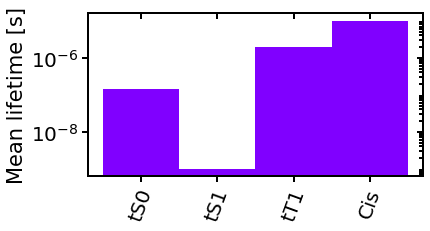

In [37]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="mean")

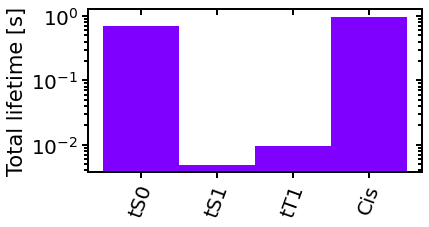

In [38]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="total")

### State occurrences

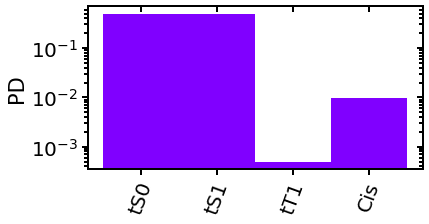

In [42]:
fig, ax = fi.FigureCollection(system).populations(mode="single_states", single_fluorophores=True,
                                                  bins=np.arange(0, 5)-0.5)

## 0.1 µs

In [12]:
system.emitters(unit="s", resample="0.1us", photon_collection=0.1)

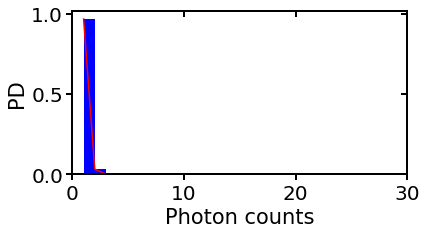

In [13]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=3,
                                                      xlim=[0, 30], pois=True)

## 1 µs

In [14]:
system.emitters(unit="s", resample="1us", photon_collection=0.1)

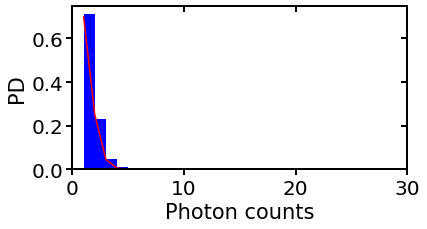

In [15]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=6,
                                                      xlim=[0, 30], pois=True)

## 10 µs

In [6]:
system.emitters(unit="s", resample="10us", photon_collection=0.1)

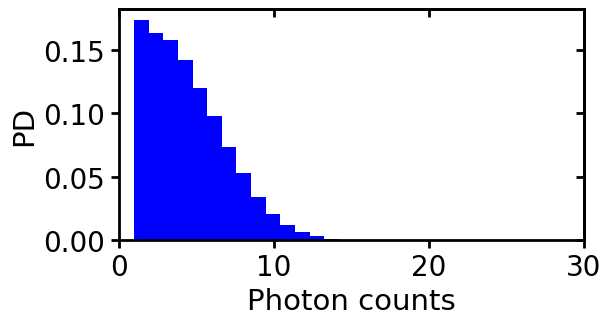

In [11]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=18,
                                                      xlim=[0, 30])#, pois=True)
fig.savefig(r'C:\Users\SagixOffice\OneDrive - Universität Würzburg\Notebooks, plots\Plots\10µs_S0_S1_T1_Cis', bbox_inches='tight')

## 0.1 ms

In [7]:
system.emitters(resample="0.1ms", photon_collection=1)

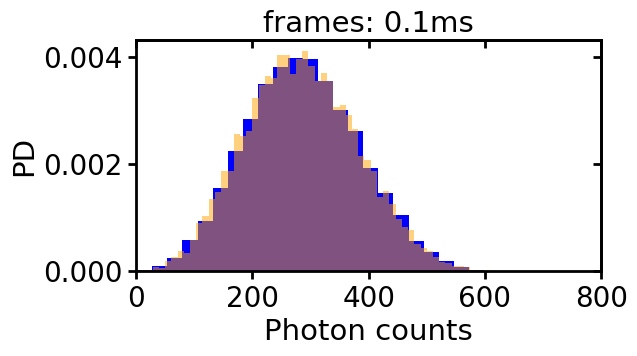

In [42]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=26,
                                                      xlim=[0, 800])

## 1 ms

In [20]:
system.emitters(unit="s", resample="1ms", photon_collection=0.1)

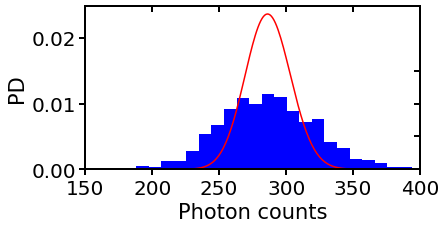

In [21]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=24,
                                                      xlim=[150, 400], pois=True)

## 10 ms

In [22]:
system.emitters(unit="s", resample="10ms", photon_collection=0.1)

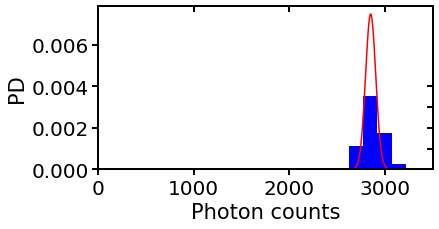

In [23]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=20,
                                                      xlim=[0, 3500], pois=True)